# Investigating the approximation with the phantom

In [1]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, sosfilt

%matplotlib widget

## Data loading and setting definition

In [2]:
pressure = np.load(r'../Data/Phantom_measurement/GT_Pressure.npy')

In [3]:
raw_dataset = np.load(r'../Data/Phantom_measurement/Phantom_raw_dataset.npy')

In [4]:
fs = 2e9
fs_res = 5e6

### Plotting enveloped US response

(1450, 50000)
(50000,)
[-12 -10  -9 ... -17 -18 -18]
[0.0000000e+00 3.8500000e-04 7.7000000e-04 ... 1.9248845e+01 1.9249230e+01
 1.9249615e+01]


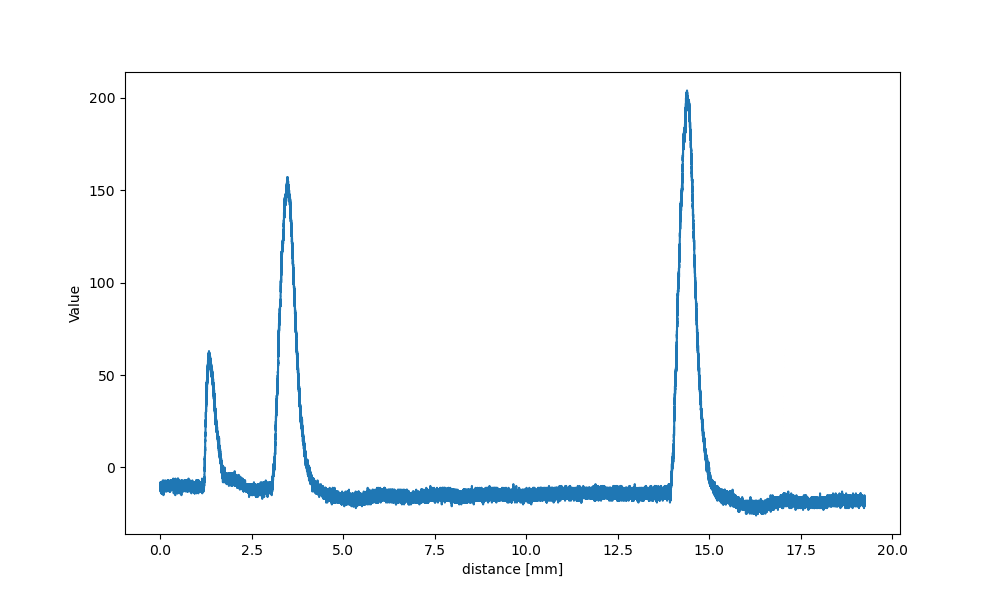

In [5]:
print(raw_dataset.shape)
print(raw_dataset[0].shape)

raw_data = raw_dataset[0]
print(raw_data)
distance =  np.arange(len(raw_data))* 1/fs * 1540 / 2 * 1000
print(distance)

plt.figure(figsize=(10, 6))
plt.plot(distance, raw_data)
plt.ylim(np.min(raw_data)-10, np.max(raw_data)+10)
plt.xlabel("distance [mm]")
plt.ylabel("Value")
plt.show()

(1450, 125)


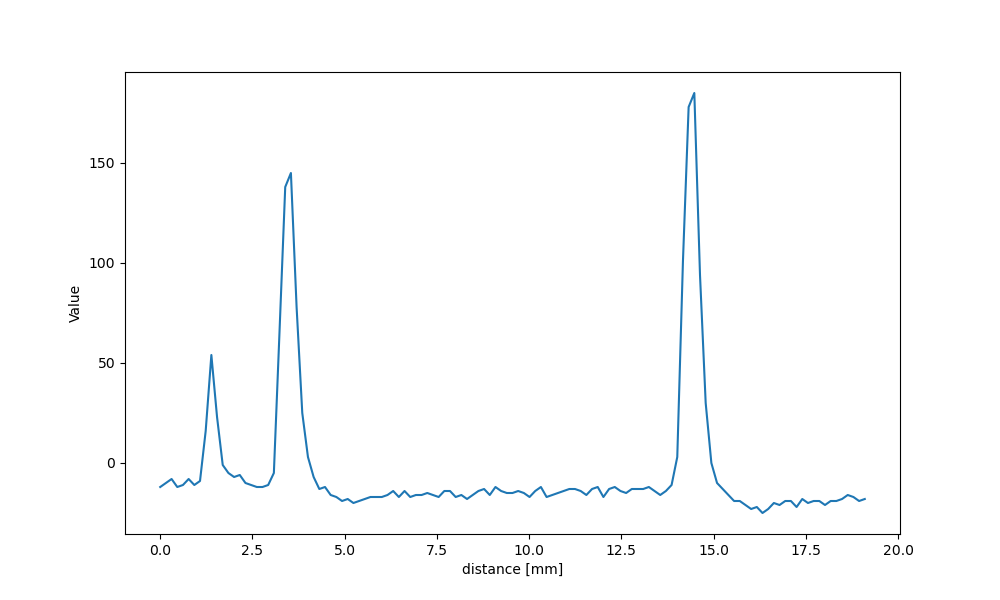

In [6]:
# Downsampling
raw_dataset = raw_dataset[:,::int(fs/fs_res)]
distance_rs = distance[::int(fs/fs_res)]

print(raw_dataset.shape)

plt.figure(figsize=(10, 6))
plt.plot(distance_rs, raw_dataset[0])
plt.xlabel("distance [mm]")
plt.ylabel("Value")
plt.show()

12
110
(1450, 98)


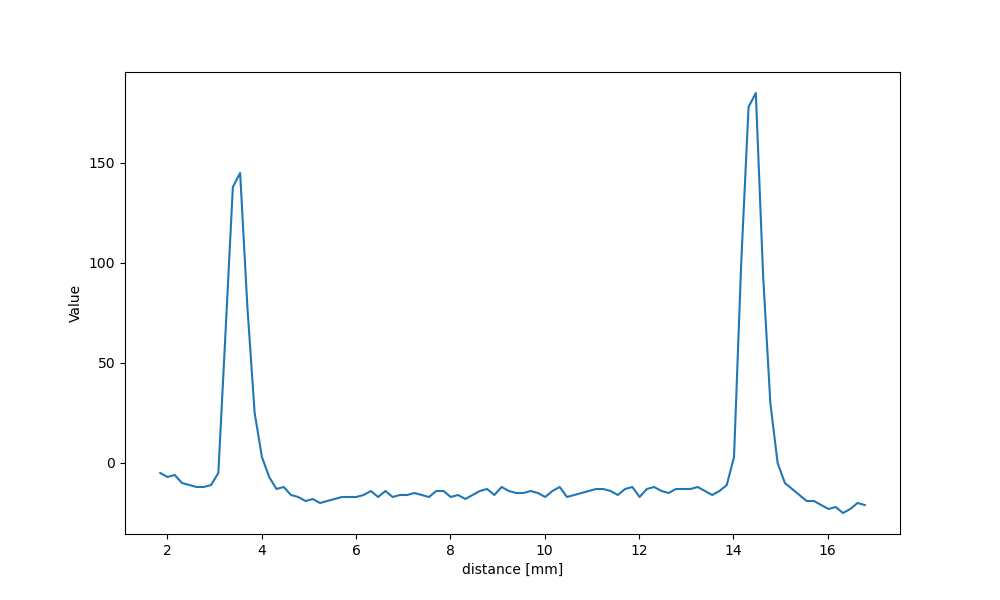

In [7]:
idx_2mm = int(2*fs_res*2//(1540*1000))
idx_17mm = int(17*fs_res*2//(1540*1000))

print(idx_2mm)
print(idx_17mm)

raw_dataset = raw_dataset[:,idx_2mm:idx_17mm]
distance_rs = distance_rs[idx_2mm:idx_17mm]

print(raw_dataset.shape)

plt.figure(figsize=(10, 6))
plt.plot(distance_rs, raw_dataset[0])
plt.xlabel("distance [mm]")
plt.ylabel("Value")
plt.show()

### Butterworth filters with numerically stable sos type

In [8]:
def butter_lowpass(cutoff, fs, order):
    normal_cutoff = cutoff / (0.5*fs)
    sos = butter(order, normal_cutoff,btype='low', output='sos')
    return sos
def butter_lowpass_filtfilt(data, cutoff, fs, order):
    sos = butter_lowpass(cutoff, fs, order=order)
    y_temp = sosfilt(sos, data)
    y_temp = y_temp[::-1]
    y = sosfilt(sos, y_temp)
    y = y[::-1]
    return y
def butter_lowpass_filtfilt_test(data, cutoff, fs, order):
    sos = butter_lowpass(cutoff, fs, order=order)
    y_temp = sosfilt(sos, data)
    y_temp = y_temp[::-1]
    y = sosfilt(sos, y_temp)
    y = y[::-1]
    return y,sos
def butter_lowpass_filtfilt_short(data, cutoff, fs, order):
    sos = butter_lowpass(cutoff, fs, order=order)
    y = sosfiltfilt(sos, data)
    return y

# Preprocessing

In [9]:
fs_new = 20 * fs_res

In [10]:
def resample(signal, original_fs, target_fs): # zero stuffing
    upsample_factor = int(target_fs / original_fs)
    
    upsampled_signal = np.zeros(1948)
    upsampled_signal[::upsample_factor] = signal

    mandatory_cut_off = 1000000

    output = butter_lowpass_filtfilt(upsampled_signal, mandatory_cut_off, fs=target_fs, order=4)

    return output

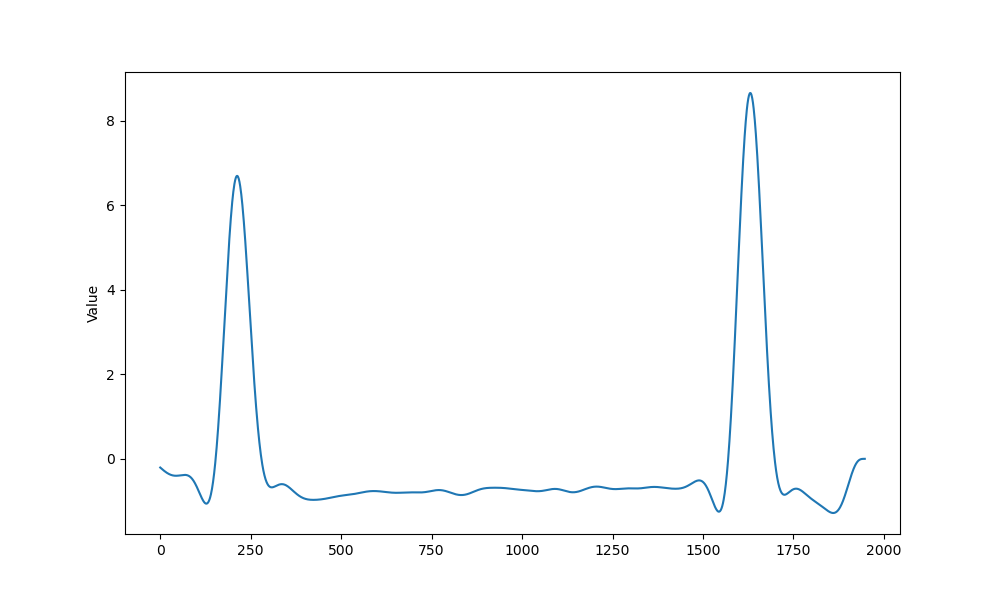

In [11]:
resampled_signal = resample(raw_dataset[0], fs_res, fs_new)

plt.figure(figsize=(10, 6))
plt.plot(resampled_signal)
plt.ylabel("Value")
plt.show()

In [12]:
new_raw_dataset = []
for i in range(len(raw_dataset)):
    new_raw_dataset.append(resample(raw_dataset[i], fs_res, fs_new))

new_raw_dataset = np.array(new_raw_dataset)
raw_dataset = new_raw_dataset

In [13]:
idx_2mm = int(2*fs_new*2//(1540*1000))
idx_17mm = int(17*fs_new*2//(1540*1000))

data_interest = raw_dataset
distance_fs_new = distance[::int(fs/fs_new)]
distance_interest = distance_fs_new[idx_2mm:idx_17mm]

print(data_interest.shape)
print(distance_interest.shape)

(1450, 1948)
(1948,)


In [14]:
data_interest = np.floor(data_interest*(512)) # using integer values to promote embedded implementation

In [15]:
def sliding_window_covariance(x, y, window_size):
    N = len(x)
    cov_result = np.zeros(N)

    for i in range(window_size//2, N - window_size//2):
        x_window = x[i-window_size//2:i+window_size//2+1]
        y_window = y[i-window_size//2:i+window_size//2+1]
        cov_result[i] = np.sum(x_window*y_window)/2**16

    cov_result[cov_result < 0.05*np.max(cov_result)] = 0

    return cov_result

# Wall detection

In [16]:
R = data_interest
print(len(R))

1450


In [17]:
W1 = []
W2 = []
all_peaks = []
W = int(0.5*fs_new*2//(1540*1000))
tester_num = 8

for i in range(tester_num):
    swc = sliding_window_covariance(R[i], R[i+1], W)
    peaks, _ = signal.find_peaks(swc)
    all_peaks.append(peaks)  

max_len = max(len(sublist) for sublist in all_peaks)
array_shape = (len(all_peaks), max_len)
result_array = np.full(array_shape, np.nan)
for i, sublist in enumerate(all_peaks):
    result_array[i, :len(sublist)] = sublist
all_peaks = result_array

#print(all_peaks)

for i in range(0,all_peaks.shape[0]):
    S = []
    for j in range(all_peaks.shape[1]):
        try:
            W0 = R[0][int(all_peaks[i,j]-W):int(all_peaks[i,j]+W)]
            Wm = R[i+1][int(all_peaks[i,j]-W):int(all_peaks[i,j]+W)]
            peaks_0 = np.argmax(W0)
            peaks_m = np.argmax(Wm)
            S.append(peaks_m-peaks_0)
        except:
            S.append(np.nan)
    #print(S)
    correct_pair_corr = []
    for j in range(len(S)-1):
        if np.isnan(S[j]) or np.isnan(S[j+1]):
            correct_pair_corr.append(np.inf)
        else:
            correct_pair_corr.append(S[j]*S[j+1])
    if len(correct_pair_corr) == 0:
        W1.append(np.nan)
        W2.append(np.nan)
    else:
        best_idx = np.argmin(correct_pair_corr)
        #print(correct_pair_corr)
        #print(correct_pair_corr[best_idx])
        #print(best_idx)
        #print(all_peaks[i,best_idx])
        #print(all_peaks[i,best_idx+1])
        W1.append(all_peaks[i,best_idx])
        W2.append(all_peaks[i,best_idx+1])
    print()

W1 = np.array(W1)
W2 = np.array(W2)

W1 = W1[~np.isnan(W1)]
W2 = W2[~np.isnan(W2)]

Wall1 = int(np.median(W1))
Wall2 = int(np.median(W2))

# Wall tracking

In [18]:
Proximal_wall = []
Distal_wall = []

not_proper = 0

for i in range(len(R)):
    W_p = R[i][Wall1-W:Wall1+W+1]
    W_d = R[i][Wall2-W:Wall2+W+1]
    peaks_p = np.argmax(W_p)
    peaks_d = np.argmax(W_d) 
    Proximal_wall.append(distance_interest[Wall1+peaks_p-W])
    Distal_wall.append(distance_interest[Wall2+peaks_d-W])      



Proximal_wall = np.array(Proximal_wall)
Distal_wall = np.array(Distal_wall)
diameter = Distal_wall - Proximal_wall

# Evaluation

In [19]:
correlation_coef = np.corrcoef(Proximal_wall, Distal_wall)[0][1]
print(f"Correlation: {correlation_coef}")
if correlation_coef < 0:
    print("The measurement was correct!")
else:
    print("The measurement was not correct!")

Correlation: -0.9039453574146412
The measurement was correct!


In [20]:
DS = np.max(diameter[0:40])
DD = np.min(diameter[0:40])
SBP = np.max(pressure[0:40])
DBP = np.min(pressure[0:40])

beta = np.log(SBP/DBP)/((DS-DD)/DD)
P = DBP*np.exp(beta*((diameter-DD)/DD))
print(len(P))

1450


In [21]:
P_new = butter_lowpass_filtfilt_short(P,6,25,2)

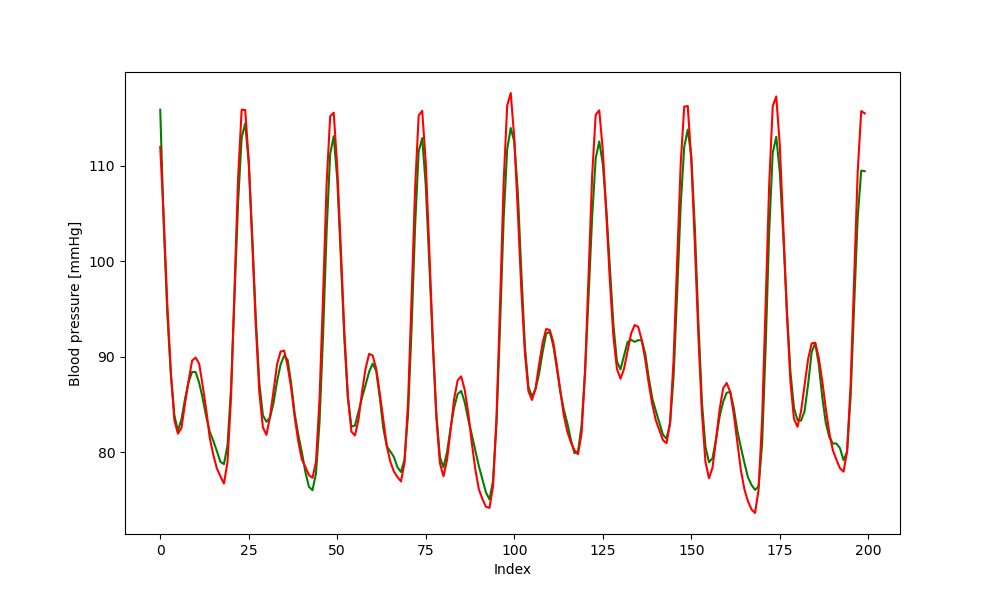

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(P_new[0:200], color='g')
plt.plot(pressure[0:200], color='r')
plt.xlabel("Index")
plt.ylabel("Blood pressure [mmHg]")
plt.show()